In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql
from dateutil.parser import parse

In [38]:
f = "../osm/007_CB_aa/run/eplusout.sql"
aa = read_sql(f,alias=True).data
aa = aa[aa.index.year==2006]
aa

variable_name,ESTE IDEAL LOADS AIR SYSTEM:Zone Ideal Loads Zone Total Cooling Energy (J),ESTE:Zone Air Relative Humidity (%),ESTE:Zone Air Temperature (C),Ti_ESTE,To,OESTE IDEAL LOADS AIR SYSTEM:Zone Ideal Loads Zone Total Cooling Energy (J),OESTE:Zone Air Relative Humidity (%),OESTE:Zone Air Temperature (C),Ti_OESTE
date,,,,,,,,,
2006-01-01 00:10:00,0.000000,NaN,NaN,24.034925,NaN,277224.068605,NaN,NaN,20.0
2006-01-01 00:20:00,0.000000,NaN,NaN,23.930461,NaN,263971.286707,NaN,NaN,20.0
2006-01-01 00:30:00,0.000000,NaN,NaN,23.827980,NaN,251053.777571,NaN,NaN,20.0
2006-01-01 00:40:00,0.000000,NaN,NaN,23.727139,NaN,238517.773899,NaN,NaN,20.0
2006-01-01 00:50:00,0.000000,NaN,NaN,23.627973,NaN,226365.196577,NaN,NaN,20.0
...,...,...,...,...,...,...,...,...,...
2006-12-31 23:10:00,59574.351221,NaN,NaN,25.000000,NaN,494338.388815,NaN,NaN,20.0
2006-12-31 23:20:00,51407.253331,NaN,NaN,25.000000,NaN,478541.926915,NaN,NaN,20.0
2006-12-31 23:30:00,43335.987196,NaN,NaN,25.000000,NaN,462901.793326,NaN,NaN,20.0


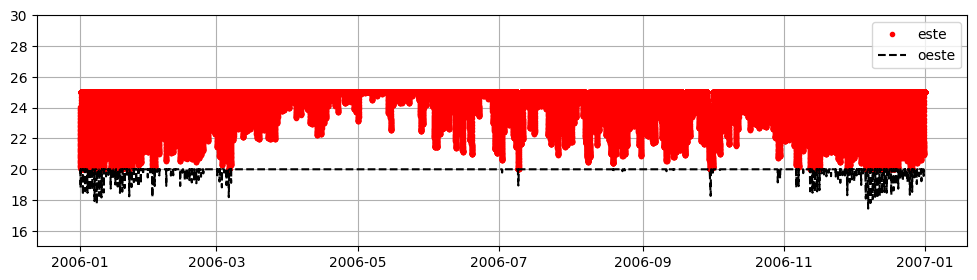

In [16]:
fig, ax = plt.subplots(figsize=(12,3))

ax.plot(aa.Ti_ESTE,"r.",label="este")
ax.plot(aa.Ti_OESTE,"k--",label="oeste")

ax.set_ylim(15,30)
ax.grid()
ax.legend()

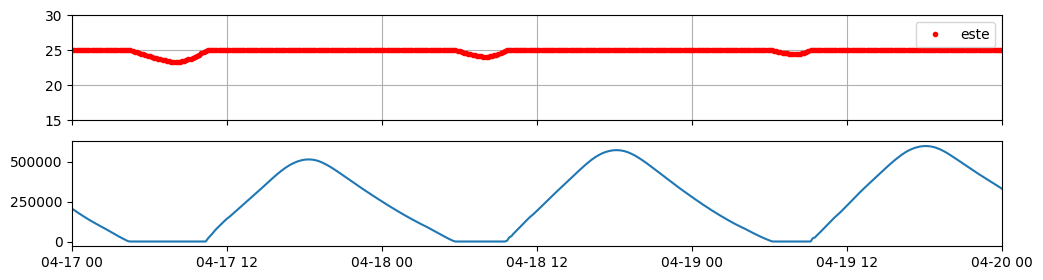

In [23]:
fig, (ax,ax2) = plt.subplots(2,1,figsize=(12,3),sharex=True)

f1 = parse("2006-04-17")
f2 = f1 + pd.Timedelta("3D")

ax.plot(aa.Ti_ESTE,"r.",label="este")


ax2.plot(aa["ESTE IDEAL LOADS AIR SYSTEM:Zone Ideal Loads Zone Total Cooling Energy (J)"])

ax.set_ylim(15,30)
ax.set_xlim(f1,f2)
ax.grid()
ax.legend()

<BarContainer object of 13 artists>

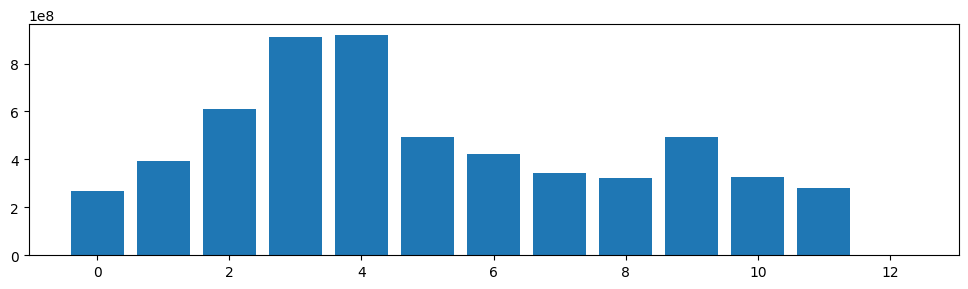

In [28]:
zona = "ESTE IDEAL LOADS AIR SYSTEM:Zone Ideal Loads Zone Total Cooling Energy (J)"

fig, ax = plt.subplots(figsize=(12,3) )

ax.bar(
    range(13),
    aa[zona].resample("ME").sum()
)

In [32]:
aa.columns

Index(['ESTE IDEAL LOADS AIR SYSTEM:Zone Ideal Loads Zone Total Cooling Energy (J)',
       'ESTE:Zone Air Relative Humidity (%)', 'ESTE:Zone Air Temperature (C)',
       'Ti_ESTE', 'To',
       'OESTE IDEAL LOADS AIR SYSTEM:Zone Ideal Loads Zone Total Cooling Energy (J)',
       'OESTE:Zone Air Relative Humidity (%)',
       'OESTE:Zone Air Temperature (C)', 'Ti_OESTE'],
      dtype='str', name='variable_name')

In [44]:
aa[[este,oeste]].resample("YE").sum().values

array([[5.78833154e+09, 2.30698337e+10]])

<BarContainer object of 2 artists>

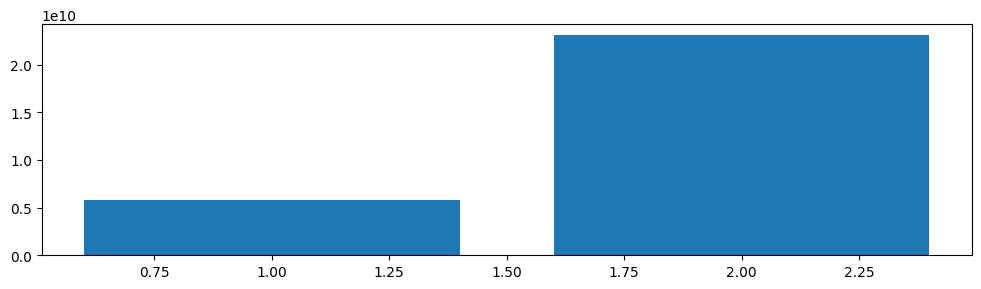

In [46]:
este = "ESTE IDEAL LOADS AIR SYSTEM:Zone Ideal Loads Zone Total Cooling Energy (J)"
oeste = "OESTE IDEAL LOADS AIR SYSTEM:Zone Ideal Loads Zone Total Cooling Energy (J)"

fig, ax = plt.subplots(figsize=(12,3) )

ax.bar(
    [1,2],
    aa[[este,oeste]].resample("YE").sum().values.flatten()
)